In [53]:
import numpy as np
import joblib
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Load test data and scaler
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")
scaler_target = joblib.load('../models/scaler_target.joblib')

# Inverse transform to Celsius
y_true = scaler_target.inverse_transform(y_test)
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_test: (3104, 7, 20)
Shape of y_test: (3104, 1)


In [54]:
# Load pre-trained models
model_lstm = tf.keras.models.load_model('../models/weather_predictor_LSTM.keras')
model_transformer = tf.keras.models.load_model('../models/weather_predictor_transformer.keras')

In [55]:
# Generate predictions
y_pred_naive = y_true[:-1]
y_true_aligned = y_true[1:]

y_pred_lstm = scaler_target.inverse_transform(model_lstm.predict(X_test, verbose=0))
y_pred_transformer = scaler_target.inverse_transform(model_transformer.predict(X_test, verbose=0))

In [56]:
# Calculate MAE
mae_naive = mean_absolute_error(y_true_aligned, y_pred_naive)
mae_lstm = mean_absolute_error(y_true, y_pred_lstm)
mae_transformer = mean_absolute_error(y_true, y_pred_transformer)

rmse_naive =np.sqrt(mean_squared_error(y_true_aligned, y_pred_naive))
rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred_lstm))
rmse_transformer =np.sqrt( mean_squared_error(y_true, y_pred_transformer))

# Print comparison
print(f"Naive Baseline MAE: {mae_naive:.2f}°C")
print(f"LSTM MAE:             {mae_lstm:.2f}°C")
print(f"Transformer MAE:      {mae_transformer:.2f}°C")

print(f"Naive Baseline RMSE: {rmse_naive:.2f}°C")
print(f"LSTM RMSE:             {rmse_lstm:.2f}°C")
print(f"Transformer RMSE:      {rmse_transformer:.2f}°C")


Naive Baseline MAE: 1.67°C
LSTM MAE:             2.18°C
Transformer MAE:      2.24°C
Naive Baseline RMSE: 2.26°C
LSTM RMSE:             2.93°C
Transformer RMSE:      3.02°C


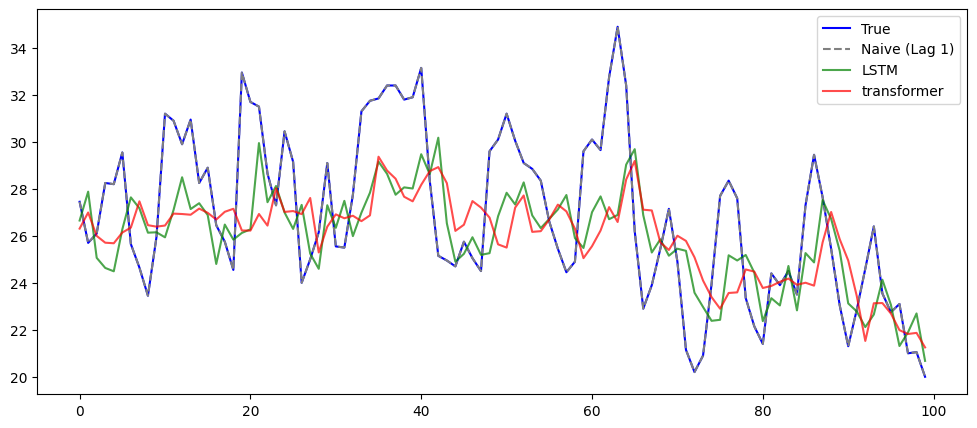

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(y_true[:100], label='True', color='blue')
plt.plot(y_pred_naive[:100], label='Naive (Lag 1)', color='gray', linestyle='--')
plt.plot(y_pred_lstm[:100], label='LSTM', color='green', alpha=0.7)
plt.plot(y_pred_transformer[:100], label='transformer', color='red', alpha=0.7)

plt.legend()
plt.show()